# Notebook 4: Machine Learning Classification
## Songwriter Style Analysis - Attribution Model Training

**Objective**: Build ML models to identify songwriters from lyrics

**Input**: songs_with_features.csv (from Notebook 3)

**Outputs**:
- Trained classification models
- Performance metrics and evaluation
- Feature importance analysis
- Interactive prediction tool

## Step 1: Import Libraries

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Load Data with Features

In [3]:
# Load data
print("Loading data with features...")
print("="*60)

df = pd.read_csv('data/songs_with_features.csv')

print(f"[SUCCESS] Loaded {len(df)} songs")
print(f"\nSongwriters: {df['target_songwriter'].nunique()}")
print(f"\nClass distribution:")
print(df['target_songwriter'].value_counts())

print("\n" + "="*60)

Loading data with features...
[SUCCESS] Loaded 381 songs

Songwriters: 4

Class distribution:
target_songwriter
Max Martin       110
Dr. Luke         107
Jack Antonoff    100
Ryan Tedder       64
Name: count, dtype: int64



## Step 3: Prepare Features and Labels

In [4]:
# Prepare features and labels
print("Preparing features and labels...")
print("="*60)

# Text features (processed lyrics)
X_text = df['lyrics_processed'].fillna('')

# Stylometric features
stylometric_features = [
    'word_count',
    'unique_word_count',
    'lexical_diversity',
    'avg_word_length',
    'word_length_variance',
    'short_word_ratio',
    'long_word_ratio',
    'very_long_word_ratio'
]
X_stylometric = df[stylometric_features].fillna(0)

# Sentiment features
sentiment_features = [
    'sentiment_polarity',
    'sentiment_subjectivity'
]
X_sentiment = df[sentiment_features].fillna(0)

# Labels
y = df['target_songwriter']

print(f"Text samples: {len(X_text)}")
print(f"Stylometric features: {len(stylometric_features)}")
print(f"Sentiment features: {len(sentiment_features)}")
print(f"Labels: {len(y)}")
print(f"Classes: {y.nunique()}")

print("\n" + "="*60)

Preparing features and labels...
Text samples: 381
Stylometric features: 8
Sentiment features: 2
Labels: 381
Classes: 4



## Step 4: TF-IDF Vectorization

In [5]:
# Create TF-IDF features
print("Creating TF-IDF features...")
print("="*60)

# Word-level TF-IDF
tfidf_word = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)
X_tfidf_word = tfidf_word.fit_transform(X_text)

print(f"[OK] Word TF-IDF shape: {X_tfidf_word.shape}")

# Character-level TF-IDF (captures style better)
tfidf_char = TfidfVectorizer(
    analyzer='char',
    max_features=1000,
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.8
)
X_tfidf_char = tfidf_char.fit_transform(X_text)

print(f"[OK] Character TF-IDF shape: {X_tfidf_char.shape}")

# Combine all features
from scipy.sparse import hstack

X_combined = hstack([
    X_tfidf_word,
    X_tfidf_char,
    X_stylometric.values,
    X_sentiment.values
])

print(f"\n[SUCCESS] Combined feature matrix shape: {X_combined.shape}")
print(f"  - Word TF-IDF: 1000 features")
print(f"  - Character TF-IDF: 1000 features")
print(f"  - Stylometric: {len(stylometric_features)} features")
print(f"  - Sentiment: {len(sentiment_features)} features")
print(f"  - Total: {X_combined.shape[1]} features")

print("\n" + "="*60)

Creating TF-IDF features...
[OK] Word TF-IDF shape: (381, 1000)
[OK] Character TF-IDF shape: (381, 1000)

[SUCCESS] Combined feature matrix shape: (381, 2010)
  - Word TF-IDF: 1000 features
  - Character TF-IDF: 1000 features
  - Stylometric: 8 features
  - Sentiment: 2 features
  - Total: 2010 features



## Step 5: Encode Labels

In [6]:
# Encode labels
print("Encoding labels...")
print("="*60)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for idx, songwriter in enumerate(label_encoder.classes_):
    count = sum(y_encoded == idx)
    print(f"  {idx}: {songwriter} ({count} songs)")

print("\n" + "="*60)

Encoding labels...
Label mapping:
  0: Dr. Luke (107 songs)
  1: Jack Antonoff (100 songs)
  2: Max Martin (110 songs)
  3: Ryan Tedder (64 songs)



## Step 6: Train-Test Split

In [7]:
# Split data
print("Splitting data into train and test sets...")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} songs")
print(f"Test set: {X_test.shape[0]} songs")
print(f"Feature dimensions: {X_train.shape[1]}")

print("\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[label]}: {count} songs")

print("\n" + "="*60)

Splitting data into train and test sets...
Training set: 304 songs
Test set: 77 songs
Feature dimensions: 2010

Class distribution in training set:
  Dr. Luke: 85 songs
  Jack Antonoff: 80 songs
  Max Martin: 88 songs
  Ryan Tedder: 51 songs



## Step 7: Save Prepared Data

In [8]:
# Save prepared data for reproducibility
print("Saving prepared data...")
print("="*60)

# Save feature matrices
np.save('data/X_train.npy', X_train.toarray())
np.save('data/X_test.npy', X_test.toarray())
np.save('data/y_train.npy', y_train)
np.save('data/y_test.npy', y_test)

# Save vectorizers and encoder
with open('data/tfidf_word_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_word, f)

with open('data/tfidf_char_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_char, f)

with open('data/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("[SAVED] Training and test data saved")
print("[SAVED] Vectorizers and encoder saved")

print("\n" + "="*60)

Saving prepared data...
[SAVED] Training and test data saved
[SAVED] Vectorizers and encoder saved



## Step 8: Train Multiple Models

In [9]:
# Train and compare multiple models
print("Training multiple classification models...")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    'Linear SVC': LinearSVC(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
}

results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'predictions': y_pred
    }
    
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  F1 (macro): {f1_macro:.3f}")
    print(f"  F1 (weighted): {f1_weighted:.3f}")

print("\n" + "="*60)
print("Model training complete")
print("="*60)

Training multiple classification models...

Training Logistic Regression...
  Accuracy: 0.571
  F1 (macro): 0.578
  F1 (weighted): 0.569

Training Linear SVC...
  Accuracy: 0.338
  F1 (macro): 0.218
  F1 (weighted): 0.240

Training Random Forest...
  Accuracy: 0.545
  F1 (macro): 0.540
  F1 (weighted): 0.549

Model training complete


## Step 9: Model Comparison

In [10]:
# Compare model performance
print("Model Performance Comparison")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1 (Macro)': [results[m]['f1_macro'] for m in results],
    'F1 (Weighted)': [results[m]['f1_weighted'] for m in results]
}).sort_values('Accuracy', ascending=False)

print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\n[BEST MODEL] {best_model_name}")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.3f}")

print("\n" + "="*60)

Model Performance Comparison
              Model  Accuracy  F1 (Macro)  F1 (Weighted)
Logistic Regression  0.571429    0.577541       0.568804
      Random Forest  0.545455    0.539683       0.549248
         Linear SVC  0.337662    0.217758       0.240487

[BEST MODEL] Logistic Regression
  Accuracy: 0.571



## Step 10: Detailed Classification Report

In [11]:
# Generate detailed classification report for best model
print(f"Detailed Classification Report: {best_model_name}")
print("="*60)

y_pred_best = results[best_model_name]['predictions']

report = classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_,
    digits=3
)

print(report)

# Save report
with open('data/classification_report.txt', 'w') as f:
    f.write(f"Classification Report: {best_model_name}\n")
    f.write("="*60 + "\n")
    f.write(report)

print("\n[SAVED] Classification report saved to data/classification_report.txt")
print("\n" + "="*60)

Detailed Classification Report: Logistic Regression
               precision    recall  f1-score   support

     Dr. Luke      0.650     0.591     0.619        22
Jack Antonoff      0.526     0.500     0.513        20
   Max Martin      0.524     0.500     0.512        22
  Ryan Tedder      0.588     0.769     0.667        13

     accuracy                          0.571        77
    macro avg      0.572     0.590     0.578        77
 weighted avg      0.571     0.571     0.569        77


[SAVED] Classification report saved to data/classification_report.txt



## Step 11: Confusion Matrix Visualization

Creating confusion matrix...
[SAVED] Confusion matrix saved to data/confusion_matrix.png


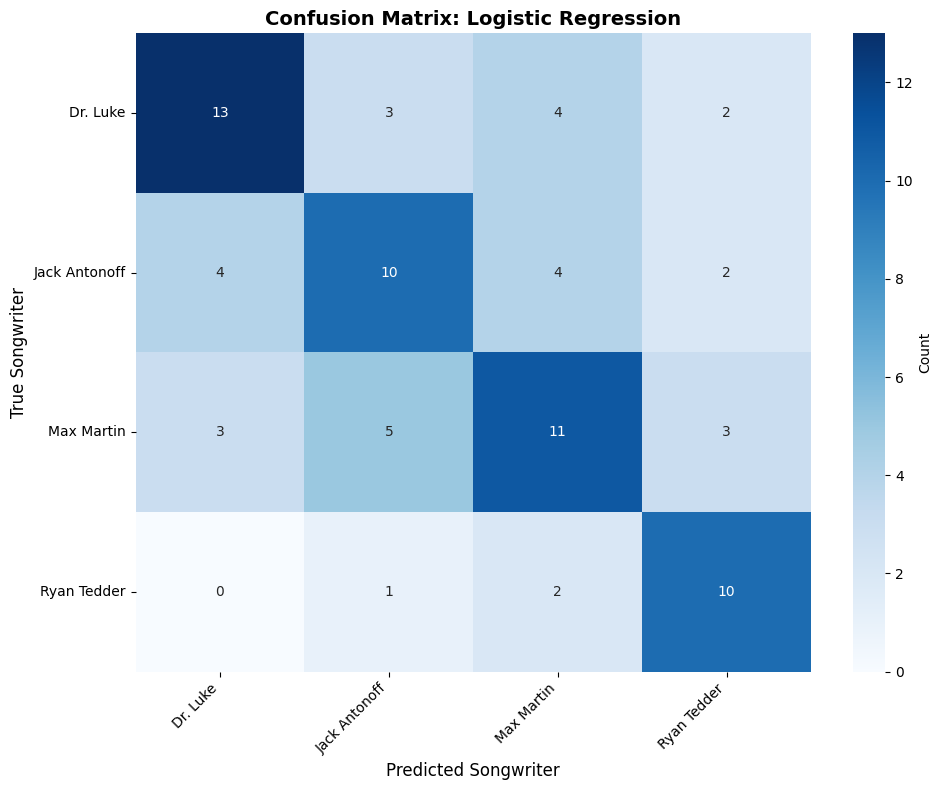

In [12]:
# Create confusion matrix visualization
print("Creating confusion matrix...")
print("="*60)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Songwriter', fontsize=12)
plt.xlabel('Predicted Songwriter', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('data/confusion_matrix.png', dpi=150, bbox_inches='tight')
print("[SAVED] Confusion matrix saved to data/confusion_matrix.png")
plt.show()

print("\n" + "="*60)

## Step 12: Feature Importance Analysis (Random Forest)

In [13]:
# Analyze feature importance (if using Random Forest)
if best_model_name == 'Random Forest':
    print("Analyzing feature importance...")
    print("="*60)
    
    # Get feature importances
    feature_importance = best_model.feature_importances_
    
    # Create feature names
    feature_names = (
        ['word_tfidf_' + str(i) for i in range(1000)] +
        ['char_tfidf_' + str(i) for i in range(1000)] +
        stylometric_features +
        sentiment_features
    )
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    # Categorize features
    def categorize_feature(name):
        if name.startswith('word_tfidf'):
            return 'Word TF-IDF'
        elif name.startswith('char_tfidf'):
            return 'Char TF-IDF'
        elif name in stylometric_features:
            return 'Stylometric'
        else:
            return 'Sentiment'
    
    importance_df['category'] = importance_df['feature'].apply(categorize_feature)
    
    # Group by category
    category_importance = importance_df.groupby('category')['importance'].sum()
    
    print("Feature Importance by Category:")
    for cat, imp in category_importance.sort_values(ascending=False).items():
        print(f"  {cat}: {imp:.3f} ({100*imp:.1f}%)")
    
    # Save top features
    importance_df.head(50).to_csv('data/feature_importance.csv', index=False)
    print("\n[SAVED] Top 50 features saved to data/feature_importance.csv")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    category_importance.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title('Feature Importance by Category', fontsize=14, fontweight='bold')
    plt.xlabel('Total Importance')
    plt.ylabel('Feature Category')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('data/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*60)
else:
    print("Feature importance analysis only available for Random Forest")
    print("="*60)

Feature importance analysis only available for Random Forest


## Step 13: Save Best Model

In [14]:
# Save the best model
print("Saving best model...")
print("="*60)

with open('data/best_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"[SAVED] {best_model_name} saved to data/best_classifier.pkl")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'accuracy': float(results[best_model_name]['accuracy']),
    'f1_macro': float(results[best_model_name]['f1_macro']),
    'f1_weighted': float(results[best_model_name]['f1_weighted']),
    'n_features': X_train.shape[1],
    'n_classes': len(label_encoder.classes_),
    'classes': list(label_encoder.classes_)
}

import json
with open('data/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("[SAVED] Model metadata saved to data/model_metadata.json")

print("\n" + "="*60)

Saving best model...
[SAVED] Logistic Regression saved to data/best_classifier.pkl
[SAVED] Model metadata saved to data/model_metadata.json



## Step 14: Interactive Prediction Tool

In [15]:
# Create prediction function
def predict_songwriter(lyrics):
    """
    Predict songwriter from lyrics
    
    Args:
        lyrics: Raw song lyrics (string)
    
    Returns:
        dict: Prediction results with probabilities
    """
    # Preprocess lyrics (same as training)
    import re
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    
    # Clean
    text = lyrics.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\(.*?\)', '', text)
    text = re.sub(r'\d*embed$', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r"[^a-zA-Z0-9\s']", '', text)
    text = text.strip()
    
    # Tokenize and lemmatize
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    processed_text = ' '.join(tokens)
    
    # Extract TF-IDF features
    X_word = tfidf_word.transform([processed_text])
    X_char = tfidf_char.transform([processed_text])
    
    # Calculate stylometric features
    words = processed_text.split()
    if len(words) > 0:
        word_lengths = [len(w) for w in words]
        stylo = np.array([[
            len(words),
            len(set(words)),
            len(set(words)) / len(words),
            np.mean(word_lengths),
            np.var(word_lengths),
            sum(1 for w in words if len(w) <= 3) / len(words),
            sum(1 for w in words if len(w) >= 7) / len(words),
            sum(1 for w in words if len(w) >= 10) / len(words)
        ]])
    else:
        stylo = np.zeros((1, 8))
    
    # Calculate sentiment
    from textblob import TextBlob
    blob = TextBlob(text)
    sentiment = np.array([[blob.sentiment.polarity, blob.sentiment.subjectivity]])
    
    # Combine features
    X_pred = hstack([X_word, X_char, stylo, sentiment])
    
    # Predict
    prediction = best_model.predict(X_pred)[0]
    predicted_songwriter = label_encoder.inverse_transform([prediction])[0]
    
    # Get probabilities (if available)
    if hasattr(best_model, 'predict_proba'):
        probabilities = best_model.predict_proba(X_pred)[0]
        prob_dict = {}
        for idx, prob in enumerate(probabilities):
            songwriter = label_encoder.inverse_transform([idx])[0]
            prob_dict[songwriter] = float(prob)
    else:
        prob_dict = {predicted_songwriter: 1.0}
    
    return {
        'predicted_songwriter': predicted_songwriter,
        'confidence': float(max(prob_dict.values())),
        'all_probabilities': prob_dict
    }

print("Interactive prediction function created")
print("="*60)
print("\nUsage: predict_songwriter(lyrics)")
print("\nExample:")
print("  result = predict_songwriter('your song lyrics here')")
print("  print(result['predicted_songwriter'])")
print("  print(result['confidence'])")

Interactive prediction function created

Usage: predict_songwriter(lyrics)

Example:
  result = predict_songwriter('your song lyrics here')
  print(result['predicted_songwriter'])
  print(result['confidence'])


## Step 15: Test Prediction Tool with Example

In [16]:
# Test the prediction tool with a sample from test set
print("Testing prediction tool...")
print("="*60)

# Get a random test sample
test_idx = np.random.choice(range(len(df)))
test_song = df.iloc[test_idx]

print(f"Test Song: {test_song['title']}")
print(f"Artist: {test_song['artist']}")
print(f"Actual Songwriter: {test_song['target_songwriter']}")
print("\n" + "-"*60)

# Predict
result = predict_songwriter(test_song['lyrics'])

print(f"\nPredicted Songwriter: {result['predicted_songwriter']}")
print(f"Confidence: {result['confidence']:.1%}")
print("\nAll Probabilities:")
for songwriter, prob in sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True):
    print(f"  {songwriter}: {prob:.1%}")

print("\n" + "="*60)
print("MACHINE LEARNING NOTEBOOK COMPLETE")
print("="*60)
print("\nAll models trained and saved successfully!")
print(f"Best model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.1%}")

Testing prediction tool...
Test Song: Hard Feelings/Loveless
Artist: Lorde
Actual Songwriter: Jack Antonoff

------------------------------------------------------------

Predicted Songwriter: Jack Antonoff
Confidence: 66.8%

All Probabilities:
  Jack Antonoff: 66.8%
  Dr. Luke: 19.0%
  Max Martin: 12.0%
  Ryan Tedder: 2.2%

MACHINE LEARNING NOTEBOOK COMPLETE

All models trained and saved successfully!
Best model: Logistic Regression
Accuracy: 57.1%


## Interactive Prediction Cell
### Paste your own lyrics below to test the model!

In [17]:
# INTERACTIVE PREDICTION
# Replace the lyrics below with any song lyrics you want to test

custom_lyrics = """
I miss the taste of a sweeter life
I miss the conversation
I'm searching for a song tonight
I'm changing all of the stations
I like to think that we had it all
We drew a map to a better place
But on that road, I took a fall
Oh, baby, why did you run away?
I was there for you in your darkest times
I was there for you in your darkest night
But I wonder, where were you
When I was at my worst, down on my knees?
And you said you had my back
So I wonder, where were you
When all the roads you took came back to me?
So I'm following the map that leads to you
The map that leads to you
Ain't nothing I can do
The map that leads to you
Following, following, following to you
The map that leads to you
Ain't nothing I can do
The map that leads to you
Following, following, following
I hear your voice in my sleep at night
Hard to resist temptation
'Cause something strange has come over me
And now, I can't get over you
No, I just can't get over you, ooh
I was there for you in your darkest times
I was there for you in your darkest night
But I wonder, where were you
When I was at my worst, down on my knees?
And you said you had my back
So I wonder, where were you
When all the roads you took came back to me?
So I'm following the map that leads to you
The map that leads to you
Ain't nothing I can do
The map that leads to you
Following, following, following to you
The map that leads to you
Ain't nothing I can do
The map that leads to you
Oh, oh, oh, ah
Oh, oh, oh, ah
Yeah, yeah, yeah, ah
Ah, ah, mm, ah
Oh, I was there for you, oh, in your darkest time
Oh, I was there for you, oh, in your darkest night
Oh, I was there for you, oh, in your darkest time
Oh, I was there for you, oh, in your darkest night
But I wonder, where were you
When I was at my worst, down on my knees?
And you said you had my back
So I wonder, where were you
When all the roads you took came back to me?
So I'm following the map that leads to you
The map that leads to you
Ain't nothing I can do
The map that leads to you
Following, following, following to you
The map that leads to you
Ain't nothing I can do
The map that leads to you
Following, following, following
"""

# Predict
if custom_lyrics.strip() and "[Paste" not in custom_lyrics:
    result = predict_songwriter(custom_lyrics)
    
    print("SONGWRITER PREDICTION RESULTS")
    print("="*60)
    print(f"\nPredicted Songwriter: {result['predicted_songwriter']}")
    print(f"Confidence: {result['confidence']:.1%}")
    
    print("\nAll Predictions:")
    for songwriter, prob in sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True):
        bar = '█' * int(prob * 50)
        print(f"  {songwriter:20s} {prob:6.1%} {bar}")
    
    print("\n" + "="*60)
else:
    print("Please paste song lyrics to analyze!")

SONGWRITER PREDICTION RESULTS

Predicted Songwriter: Ryan Tedder
Confidence: 62.2%

All Predictions:
  Ryan Tedder           62.2% ███████████████████████████████
  Max Martin            18.7% █████████
  Jack Antonoff         12.5% ██████
  Dr. Luke               6.6% ███

